In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris(as_frame=True)
df = iris.frame

# Rename target numbers to actual species names
df['target'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
df.head()

Shape: (150, 5)

Column names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                object
dtype: object


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Rename columns to shorter names
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

print("New column names:", df.columns.tolist())

New column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [4]:
# Statistical summary
print("Statistical Summary:")
print(df.describe().round(2))

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Class balance — how many flowers per species?
print("\nClass balance:")
print(df['species'].value_counts())

Statistical Summary:
       sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.06          3.76         1.20
std            0.83         0.44          1.77         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%            5.80         3.00          4.35         1.30
75%            6.40         3.30          5.10         1.80
max            7.90         4.40          6.90         2.50

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## B1 Observations

- 150 samples × 5 columns (4 features + 1 target)
- All features are float64, target is text (species name)
- Zero missing values — no cleaning needed
- Perfectly balanced — 50 samples per species
- Petal measurements have higher variance than sepal measurements
  → likely better at distinguishing species

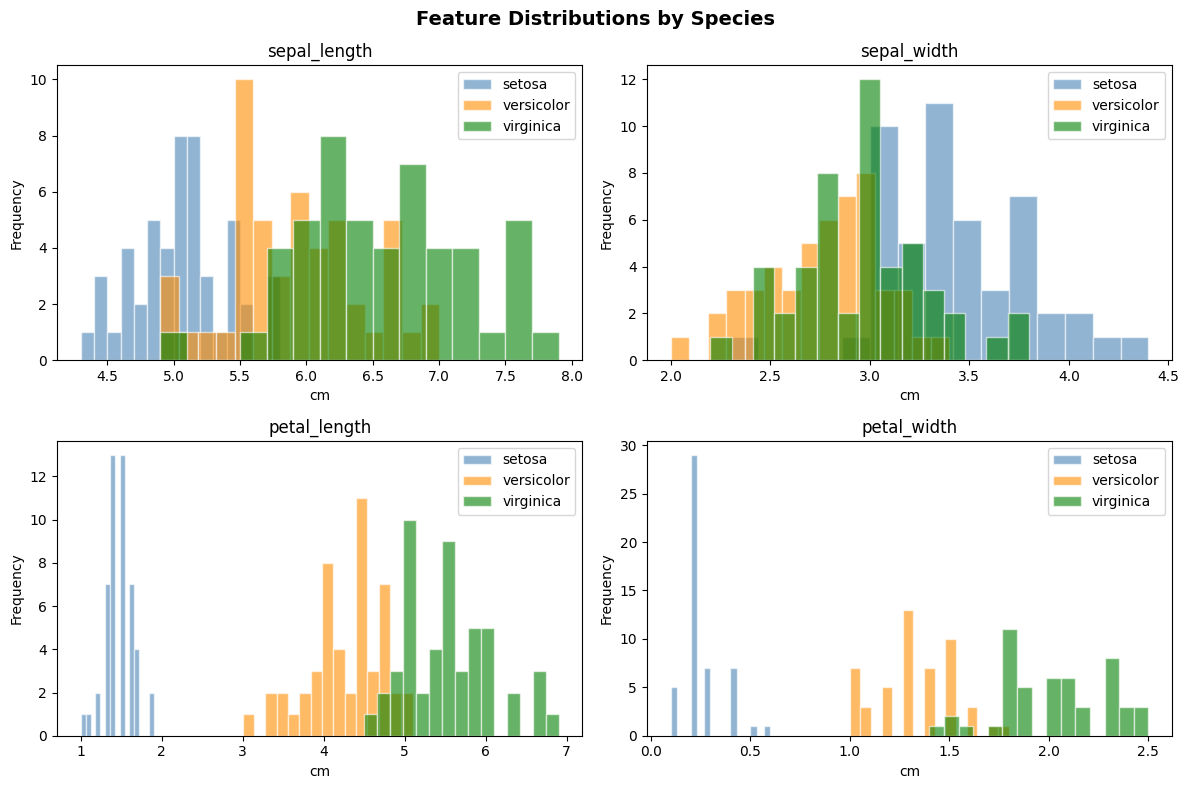

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors   = {'setosa': 'steelblue', 'versicolor': 'darkorange', 'virginica': 'green'}

for i, feature in enumerate(features):
    for species, color in colors.items():
        subset = df[df['species'] == species]
        axes[i].hist(subset[feature], bins=15, alpha=0.6,
                     color=color, label=species, edgecolor='white')
    axes[i].set_title(feature)
    axes[i].set_xlabel('cm')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5926/714291355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5926/714291355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5926/714291355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5926/714291355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


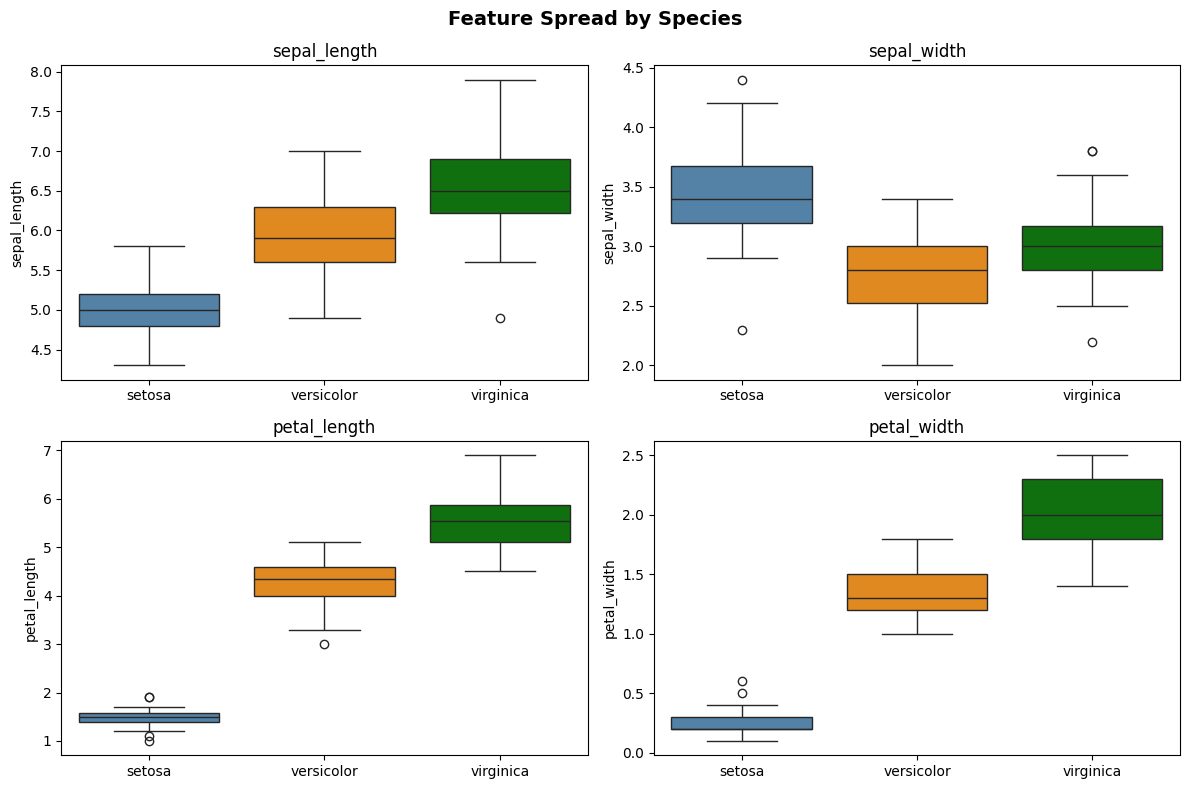

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='species',
        y=feature,
        palette={'setosa': 'steelblue', 'versicolor': 'darkorange', 'virginica': 'green'},
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

plt.suptitle('Feature Spread by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

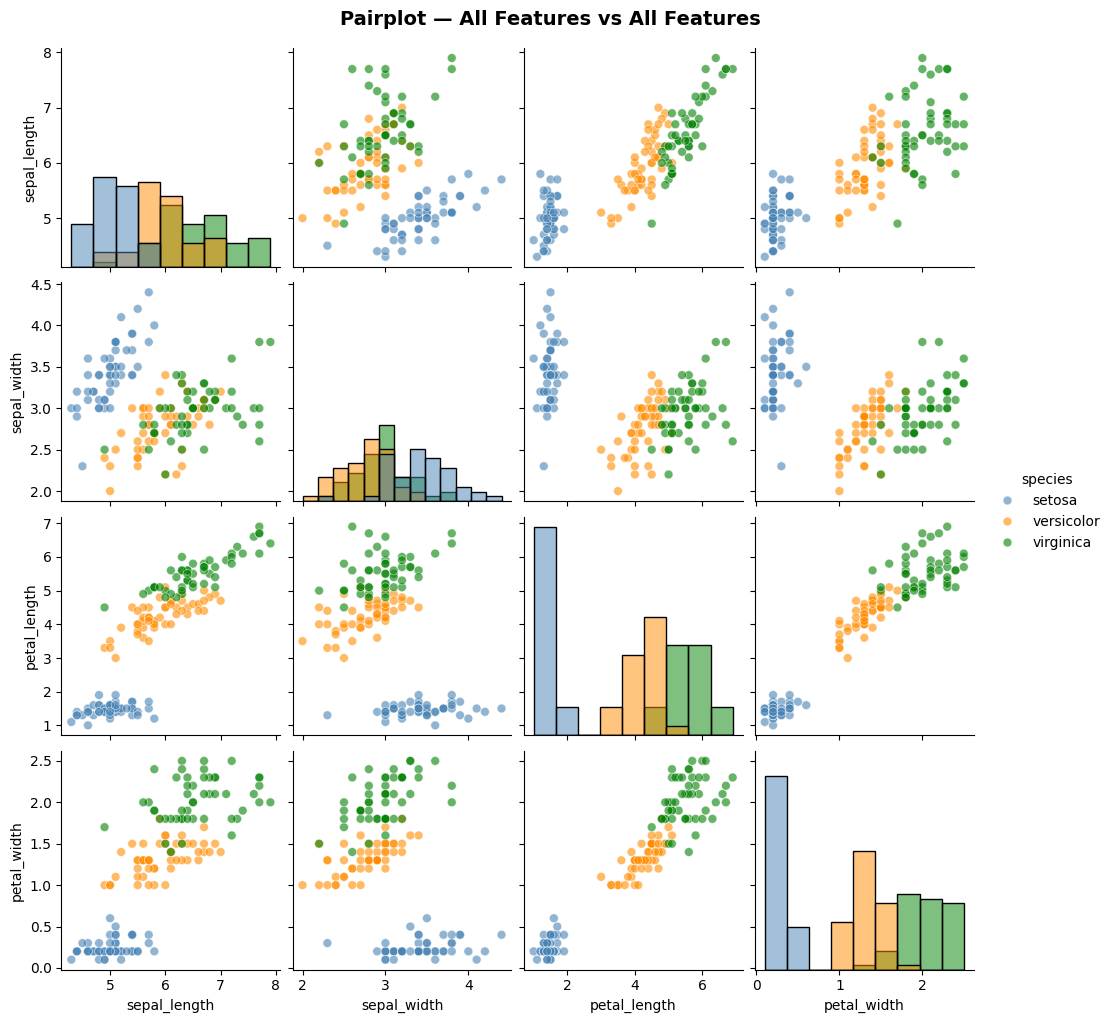

In [7]:
sns.pairplot(
    df,
    hue='species',                                          # colour by species
    palette={'setosa': 'steelblue', 'versicolor': 'darkorange', 'virginica': 'green'},
    diag_kind='hist',                                       # histogram on diagonal
    plot_kws={'alpha': 0.6, 's': 40}
)

plt.suptitle('Pairplot — All Features vs All Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

## B2 Observations

- Petal features (length & width) clearly separate all three species
- Sepal features show significant overlap — weaker predictors
- Setosa is always completely isolated — easiest to classify
- Versicolor and Virginica overlap slightly in sepal measurements
  but separate cleanly using petal measurements
- Best feature combination → petal_length + petal_width

In [8]:
# Features (X) and target (y)
X = df.drop(columns=['species'])
y = df['species']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget values:", y.unique())

Features shape: (150, 4)
Target shape: (150,)

Target values: ['setosa' 'versicolor' 'virginica']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test
    random_state=42,
    stratify=y          # keep class balance in both splits
)

print("Training size:", X_train.shape)
print("Test size:    ", X_test.shape)

# Verify class balance is maintained
print("\nTraining class balance:")
print(y_train.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())

Training size: (120, 4)
Test size:     (30, 4)

Training class balance:
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

Test class balance:
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done ✅")
print("Sample scaled row:", X_train_scaled[0].round(3))

Scaling done ✅
Sample scaled row: [-1.722 -0.332 -1.346 -1.323]


## B3 Observations

- 150 samples split into 120 train / 30 test (80/20)
- stratify=y used to maintain equal class balance in both splits
- All features scaled using StandardScaler (mean=0, std=1)
- No missing values, no outlier removal needed
- Data is ready for model training

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define all 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train all 3 and store predictions
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)          # train
    y_pred = model.predict(X_test_scaled)       # predict
    results[name] = y_pred
    print(f"✅ {name} trained")

✅ Logistic Regression trained
✅ Decision Tree trained
✅ Random Forest trained


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("=" * 50)
for name, y_pred in results.items():
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"Accuracy: {acc*100:.1f}%")
    print(classification_report(y_test, y_pred))
    print("=" * 50)


Logistic Regression
Accuracy: 93.3%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Decision Tree
Accuracy: 93.3%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Random Forest
Accuracy: 90.0%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0

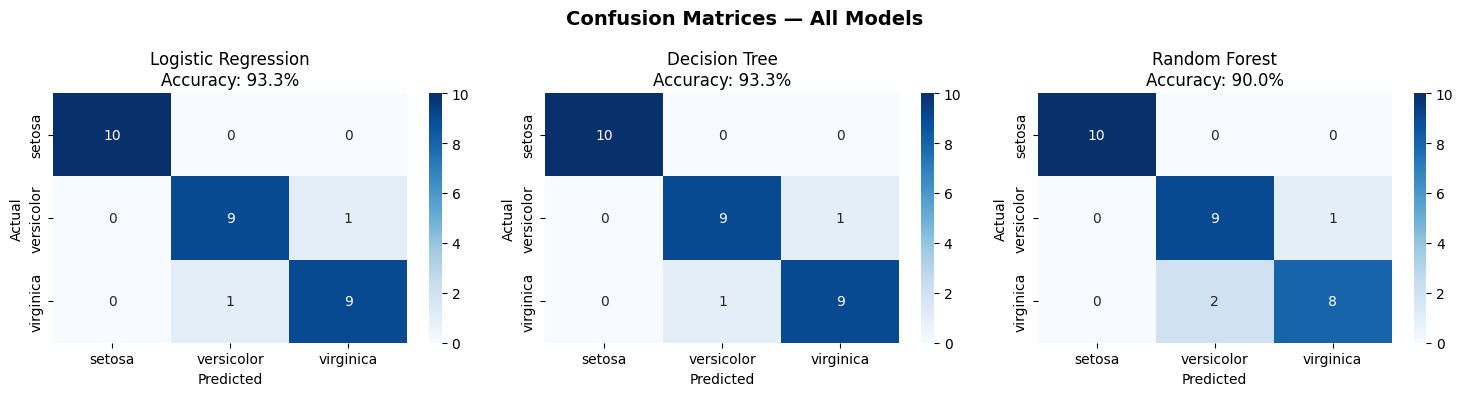

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
species_names = ['setosa', 'versicolor', 'virginica']

for i, (name, y_pred) in enumerate(results.items()):
    cm = confusion_matrix(y_test, y_pred, labels=species_names)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=species_names,
        yticklabels=species_names,
        ax=axes[i]
    )
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## B5 Observations

- All 3 models performed well (90–93% accuracy)
- Setosa was classified perfectly by every model
- All errors were between Versicolor and Virginica
  → consistent with EDA showing overlap in sepal features
- Logistic Regression and Decision Tree tied at 93.3%
- Random Forest scored 90% — small dataset limits its advantage
- Best models: Logistic Regression and Decision Tree (93.3%)

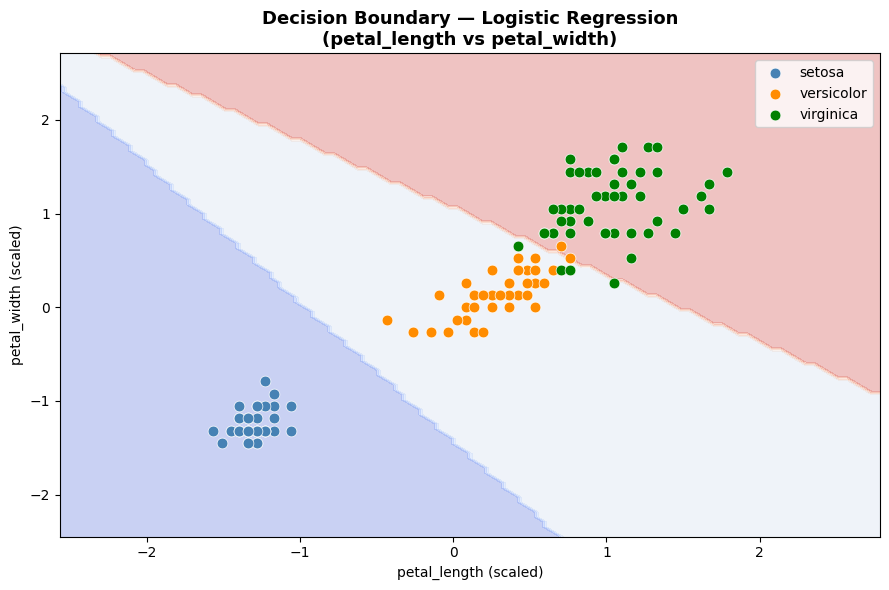

In [14]:
from sklearn.inspection import DecisionBoundaryDisplay

# Use only the 2 best features
X_2d = df[['petal_length', 'petal_width']].values
y_encoded = df['species'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2}).values

# Scale
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Train best model (Logistic Regression) on 2 features
best_model = LogisticRegression(random_state=42, max_iter=200)
best_model.fit(X_2d_scaled, y_encoded)

# Plot decision boundary
fig, ax = plt.subplots(figsize=(9, 6))

DecisionBoundaryDisplay.from_estimator(
    best_model, X_2d_scaled,
    response_method='predict',
    cmap='coolwarm', alpha=0.3, ax=ax
)

# Overlay actual data points
colors = {0: 'steelblue', 1: 'darkorange', 2: 'green'}
labels = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

for cls in [0, 1, 2]:
    mask = y_encoded == cls
    ax.scatter(
        X_2d_scaled[mask, 0],
        X_2d_scaled[mask, 1],
        color=colors[cls],
        label=labels[cls],
        edgecolor='white', s=60, linewidth=0.5
    )

ax.set_title('Decision Boundary — Logistic Regression\n(petal_length vs petal_width)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('petal_length (scaled)')
ax.set_ylabel('petal_width (scaled)')
ax.legend()
plt.tight_layout()
plt.show()

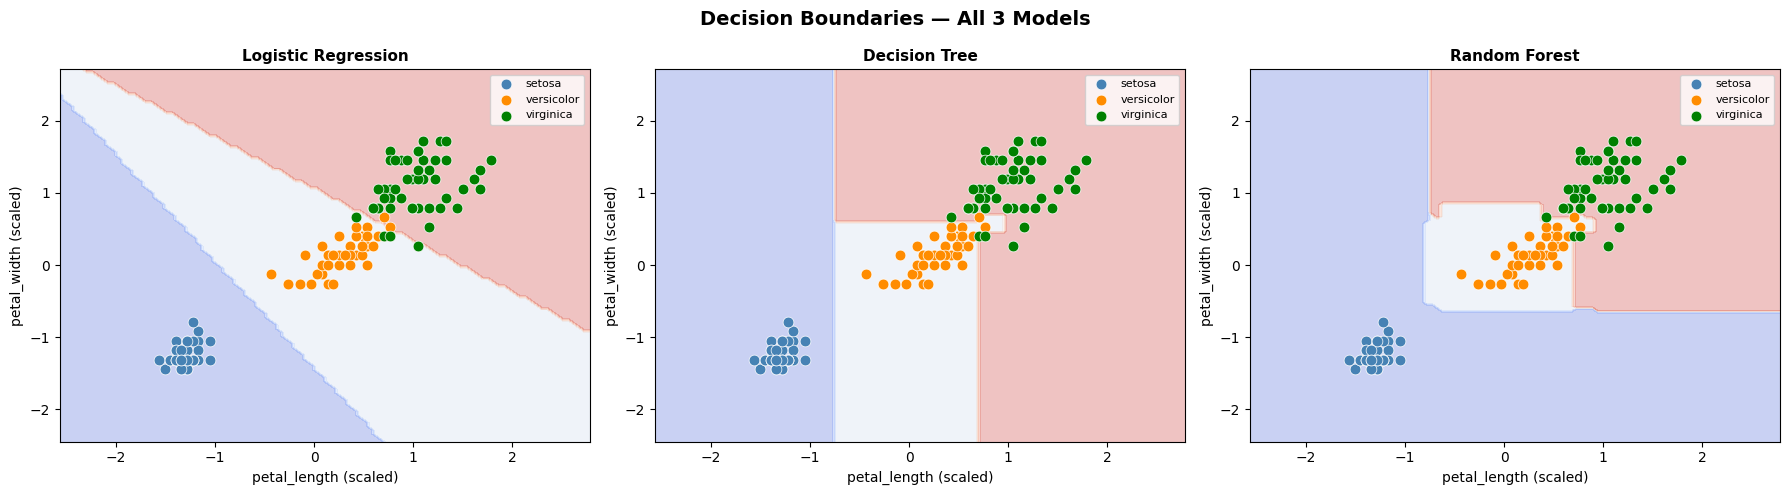

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_2d = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

for ax, (name, model) in zip(axes, model_2d.items()):
    model.fit(X_2d_scaled, y_encoded)

    DecisionBoundaryDisplay.from_estimator(
        model, X_2d_scaled,
        response_method='predict',
        cmap='coolwarm', alpha=0.3, ax=ax
    )

    for cls in [0, 1, 2]:
        mask = y_encoded == cls
        ax.scatter(
            X_2d_scaled[mask, 0],
            X_2d_scaled[mask, 1],
            color=colors[cls],
            label=labels[cls],
            edgecolor='white', s=60, linewidth=0.5
        )

    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('petal_length (scaled)')
    ax.set_ylabel('petal_width (scaled)')
    ax.legend(fontsize=8)

plt.suptitle('Decision Boundaries — All 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## B6 Observations

- Logistic Regression draws straight line boundaries — simple but effective
- Decision Tree draws rectangular boundaries — more flexible
- Random Forest draws complex irregular boundaries — most flexible
- All 3 models perfectly isolate Setosa in the bottom left
- The versicolor/virginica boundary is where all models struggle
- For this small dataset, simpler boundaries (Logistic Regression)
  generalise better than complex ones (Random Forest)

## Part C — Quiz

**Q1. Answer: D — Root Mean Squared Error (RMSE)**
RMSE takes the square root of MSE, bringing the error back to
the same units as the target variable. For house prices in $100k,
RMSE gives error in $100k — directly interpretable.

**Q2. Answer: B — 82% of the variance in the target is explained by the model**
R² measures how much of the variation in the target our model accounts for.
0.82 means the model explains 82% of why values differ across samples.
The remaining 18% is driven by factors not captured in our features.

**Q13. Regression vs Classification**
Regression predicts a continuous number as output.
Classification predicts a category or class label.

Regression example: Predicting the price of a house based on
location, size, and age — the output is a number like $320,000.

Classification example: Predicting whether an email is spam or not
spam based on its content — the output is one of two fixed categories.

We used both in this project:
- California Housing → Regression (predicting MedHouseVal)
- Iris dataset → Classification (predicting flower species)